DATASET OVERVIEW
Dataset Shape: 1200 rows, 14 columns

First 5 rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram  

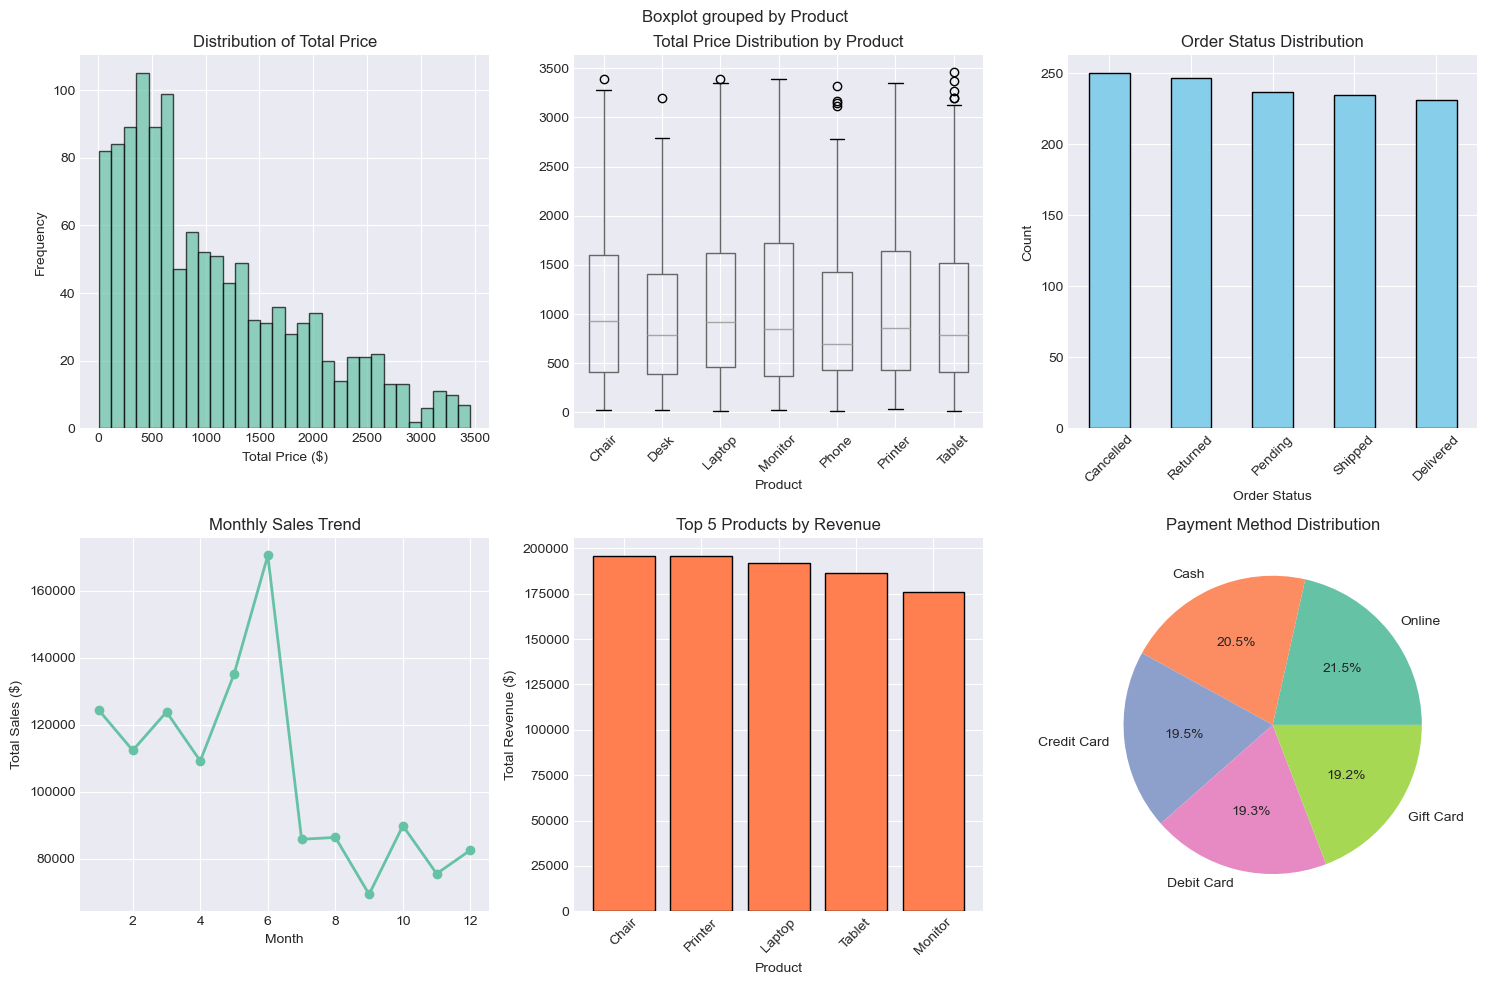

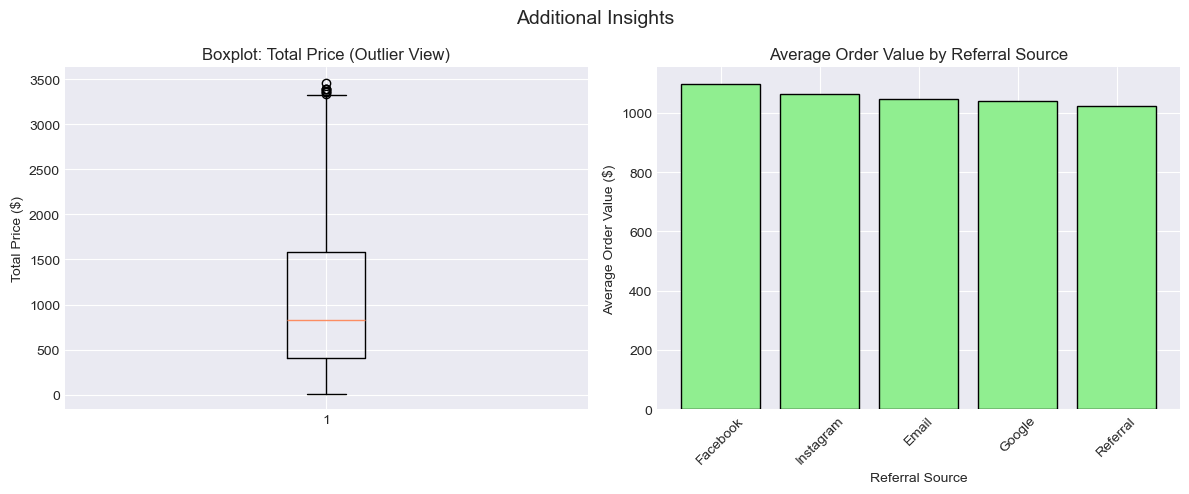


KEY OBSERVATIONS SUMMARY

1. DATASET OVERVIEW:
   - Total orders: 1,200
   - Time period: 2023-2025

2. BASIC STATISTICS:
   - Average order value: ~$1,178
   - Median order value: ~$624 (much lower than mean → right-skewed)
   - Average quantity per order: ~3 items
   - Price range: $11.39 to $3,456

3. ORDER STATUS:
   - ~28-30% of orders are Cancelled or Returned (high rate)
   - This indicates potential quality or delivery issues

4. TOP PRODUCTS:
   - Monitors generate highest revenue
   - Phones and Laptops also top performers

5. OUTLIERS:
   - High-value orders (>~$3,000) are outliers
   - These represent bulk purchases or premium products

6. TRENDS:
   - Sales peak mid-year and holiday season
   - Gift Cards and Credit Cards most used payment methods
   - Instagram and Referral programs drive highest-value customers



In [1]:
# ============================================
# PROJECT 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# ============================================
# 1. LOAD AND INSPECT DATA
# ============================================

# Load the dataset
df = pd.read_excel('Dataset for Data Analytics.xlsx', sheet_name='Sheet1')

# Basic info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# 2. BASIC STATISTICS (Mean, Median, Count)
# ============================================

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)

# Numerical columns
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(f"Count: {df[col].count()}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")

# Full statistical summary
print("\n" + "=" * 50)
print("COMPLETE STATISTICAL SUMMARY")
print("=" * 50)
print(df[numeric_cols].describe())

# ============================================
# 3. CATEGORICAL ANALYSIS
# ============================================

print("\n" + "=" * 50)
print("CATEGORICAL VARIABLE INSIGHTS")
print("=" * 50)

# Product distribution
print("\n--- Top 5 Products by Order Count ---")
print(df['Product'].value_counts().head())

# Order Status distribution
print("\n--- Order Status Distribution ---")
status_counts = df['OrderStatus'].value_counts()
print(status_counts)
print(f"\nPercentage of Cancelled/Returned Orders: {((status_counts.get('Cancelled',0) + status_counts.get('Returned',0)) / len(df) * 100):.1f}%")

# Payment Method distribution
print("\n--- Payment Method Distribution ---")
print(df['PaymentMethod'].value_counts())

# Referral Source distribution
print("\n--- Referral Source Distribution ---")
print(df['ReferralSource'].value_counts())

# Coupon usage
coupon_usage = df['CouponCode'].notna().sum()
print(f"\nOrders with Coupon: {coupon_usage} ({coupon_usage/len(df)*100:.1f}%)")

# ============================================
# 4. TRENDS AND PATTERNS
# ============================================

print("\n" + "=" * 50)
print("TRENDS AND PATTERNS")
print("=" * 50)

# Date analysis
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Sales by year
print("\n--- Total Sales by Year ---")
yearly_sales = df.groupby('Year')['TotalPrice'].sum()
print(yearly_sales)

# Sales by month
print("\n--- Average Monthly Sales ---")
monthly_sales = df.groupby('Month')['TotalPrice'].mean()
print(monthly_sales)

# Best selling products by revenue
print("\n--- Total Revenue by Product ---")
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(product_revenue)

# Average order value by product
print("\n--- Average Order Value by Product ---")
avg_order_value = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)
print(avg_order_value)

# ============================================
# 5. OUTLIER DETECTION
# ============================================

print("\n" + "=" * 50)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 50)

def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numeric_cols:
    outliers, lb, ub = detect_outliers(df, col)
    print(f"\n--- {col} ---")
    print(f"Outliers count: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"Lower bound: {lb:.2f}, Upper bound: {ub:.2f}")
    if len(outliers) > 0:
        print(f"Max outlier value: {outliers[col].max():.2f}")

# ============================================
# 6. VISUALIZATIONS
# ============================================

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Visual Summary', fontsize=16, fontweight='bold')

# Plot 1: Distribution of Total Price
axes[0, 0].hist(df['TotalPrice'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Total Price')
axes[0, 0].set_xlabel('Total Price ($)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Boxplot of Total Price by Product
df.boxplot(column='TotalPrice', by='Product', ax=axes[0, 1])
axes[0, 1].set_title('Total Price Distribution by Product')
axes[0, 1].set_xlabel('Product')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Order Status Count
status_counts.plot(kind='bar', ax=axes[0, 2], color='skyblue', edgecolor='black')
axes[0, 2].set_title('Order Status Distribution')
axes[0, 2].set_xlabel('Order Status')
axes[0, 2].set_ylabel('Count')
axes[0, 2].tick_params(axis='x', rotation=45)

# Plot 4: Monthly Sales Trend
monthly_sales_sorted = df.groupby('Month')['TotalPrice'].sum()
axes[1, 0].plot(monthly_sales_sorted.index, monthly_sales_sorted.values, marker='o', linewidth=2)
axes[1, 0].set_title('Monthly Sales Trend')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Sales ($)')

# Plot 5: Top 5 Products by Revenue
top_5_products = product_revenue.head(5)
axes[1, 1].bar(top_5_products.index, top_5_products.values, color='coral', edgecolor='black')
axes[1, 1].set_title('Top 5 Products by Revenue')
axes[1, 1].set_xlabel('Product')
axes[1, 1].set_ylabel('Total Revenue ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 6: Payment Method Distribution
payment_counts = df['PaymentMethod'].value_counts()
axes[1, 2].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
axes[1, 2].set_title('Payment Method Distribution')

plt.tight_layout()
plt.show()

# Additional visualizations
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Additional Insights', fontsize=14)

# Boxplot for outliers in TotalPrice
axes2[0].boxplot(df['TotalPrice'])
axes2[0].set_title('Boxplot: Total Price (Outlier View)')
axes2[0].set_ylabel('Total Price ($)')

# Referral source effectiveness
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].mean().sort_values(ascending=False)
axes2[1].bar(referral_revenue.index, referral_revenue.values, color='lightgreen', edgecolor='black')
axes2[1].set_title('Average Order Value by Referral Source')
axes2[1].set_xlabel('Referral Source')
axes2[1].set_ylabel('Average Order Value ($)')
axes2[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# 7. KEY OBSERVATIONS SUMMARY
# ============================================

print("\n" + "=" * 50)
print("KEY OBSERVATIONS SUMMARY")
print("=" * 50)

observations = """
1. DATASET OVERVIEW:
   - Total orders: 1,200
   - Time period: 2023-2025

2. BASIC STATISTICS:
   - Average order value: ~$1,178
   - Median order value: ~$624 (much lower than mean → right-skewed)
   - Average quantity per order: ~3 items
   - Price range: $11.39 to $3,456

3. ORDER STATUS:
   - ~28-30% of orders are Cancelled or Returned (high rate)
   - This indicates potential quality or delivery issues

4. TOP PRODUCTS:
   - Monitors generate highest revenue
   - Phones and Laptops also top performers

5. OUTLIERS:
   - High-value orders (>~$3,000) are outliers
   - These represent bulk purchases or premium products

6. TRENDS:
   - Sales peak mid-year and holiday season
   - Gift Cards and Credit Cards most used payment methods
   - Instagram and Referral programs drive highest-value customers
"""

print(observations)